# Q2 冻结模型最终样本外评价

冻结参数：

$$
W=60,\quad K_L=3,\quad K_P=2,
$$

$$
h_L=lag1,\qquad
h_P=lag1+lag7+mean7,
$$

$$
C_L=weekday7,\qquad C_P=annual1,
$$

$$
\alpha_L=0.3,\qquad \alpha_P=10.
$$

概率场景使用最近 28 天的 Load/PV 成对整日残差。

本 Notebook 展示最终冻结模型的开发期概率校准和 Sep–Dec 样本外评价结果。最终评价数据已内嵌，可单文件直接运行。


In [2]:
from io import StringIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Q2 最终样本外评价 —— 完全自包含版本
#
# 本 Notebook 已内嵌最终评价结果，不依赖任何外部 CSV，
# 因此无论放在 E:\\桌面\\CUMCM_2026\\q2\\
# 还是其他目录，都可以直接运行。
# ============================================================

_CAL_CSV = r"""period,method,score_window,calibration_error,crps_kw,cover80,cover90,width80_kw,width90_kw,expand80_kw,expand90_kw
development_May_Aug,base,0,0.14608175248419153,199.31238446143485,0.7262308039747065,0.827687443541102,783.9901432918433,984.4156415401884,0.0,0.0
development_May_Aug,rolling_conformal,14,0.0009146341463411867,199.31238446143485,0.8000225835591688,0.8991079494128276,885.4244221833563,1159.2740622428469,50.71713944575658,87.42921035132925
development_May_Aug,rolling_conformal,28,0.005329719963866553,199.31238446143485,0.7968608852755193,0.8978093947606142,878.6724528121393,1151.6581288497196,47.3411547601481,83.62124365476552
development_May_Aug,rolling_conformal,42,0.0074751580849141686,199.31238446143485,0.7957317073170733,0.8967931345980126,877.1268519023031,1148.8639123445098,46.56835430522996,82.22413540216073
development_May_Aug,rolling_conformal,60,0.006063685636856553,199.31238446143485,0.7963527551942186,0.897583559168925,877.64879073224,1150.3508484983215,46.82932372019837,82.96760347906648
"""
_SUMMARY_CSV = r"""period,probability,M,load_mae,load_rmse,pv_mae,pv_rmse,net_mae,net_rmse,crps_kw,cover80,cover90,width80_kw,width90_kw,expand80_kw,expand90_kw
development_May_Aug,chosen_calibrated,14,139.60439466219188,181.08684810002842,192.98460121890295,353.9752726762679,272.73559504848276,392.62324001128525,199.31238446143485,0.8000225835591688,0.8991079494128276,885.4244221833563,1159.2740622428469,50.71713944575658,87.42921035132925
independent_test_Sep_Dec,base,0,115.26037986367122,155.67876608035417,123.46134951191911,251.25103364403975,201.89732096509996,298.36669543801645,145.8477741954856,0.7658811475409836,0.858492714025501,620.4473578951215,784.7945714280509,0.0,0.0
independent_test_Sep_Dec,calibrated,14,115.26037986367122,155.67876608035417,123.46134951191911,251.25103364403975,201.89732096509996,298.36669543801645,145.8477741954856,0.8054417122040074,0.9016393442622951,674.0682952781538,886.0175928575145,26.810468691516107,50.61151071473181
"""
_DAILY_CSV = r"""date,crps_kw,cover80,cover90,width80_kw,width90_kw,expand80_kw,expand90_kw
2025-09-01,358.23037533795815,0.4513888888888889,0.5694444444444444,896.1459210112391,1157.536295862114,61.453915160545876,94.69509336863848
2025-09-02,445.2890828455595,0.375,0.5138888888888888,963.6858338611651,1278.2267168484946,83.21289862630692,136.2951469462323
2025-09-03,255.25455742710568,0.7777777777777778,0.9236111111111112,1070.2938546908495,1467.6552879648882,121.13299560685846,206.02439606384087
2025-09-04,221.59520060976118,0.8055555555555556,0.9375,1069.9638840019388,1459.71360923668,117.64871155625269,200.432699350368
2025-09-05,159.15825007901185,0.9375,1.0,1094.4065625946741,1463.956753458365,130.84149572770093,206.79293640848346
2025-09-06,248.2264650257162,0.8402777777777778,0.9305555555555556,1073.0035781303952,1455.0213737179174,123.53500795354375,205.7331840262823
2025-09-07,156.71659289832363,0.9583333333333334,0.9930555555555556,1099.2864350626853,1470.7244010454824,130.84149572770093,208.1604964074329
2025-09-08,288.0358438640948,0.7569444444444444,0.8680555555555556,1081.716905242868,1456.5273450893385,121.13299560685846,203.31450260512793
2025-09-09,204.10373619052586,0.9166666666666666,0.9652777777777778,1082.8605355745358,1457.1405226176548,116.13249808963383,194.18316680760154
2025-09-10,226.31344024776914,0.8819444444444444,0.9652777777777778,1086.1462916143234,1452.694406607202,116.0769477506883,189.2339207660898
2025-09-11,218.52301291052703,0.9027777777777778,0.9513888888888888,1092.4332385875916,1468.507154643413,116.13249808963383,193.11162313461546
2025-09-12,155.01104925385104,0.9652777777777778,0.9861111111111112,1089.6599687325504,1448.7753474576884,112.14329738474251,182.36960699282736
2025-09-13,185.57694369613785,0.9305555555555556,0.9722222222222222,1068.1955742102323,1423.671870092639,103.85678666781769,171.36708739039932
2025-09-14,187.25896157204042,0.8680555555555556,0.9583333333333334,1045.088212594743,1408.9662882429475,97.05398017323137,168.9712602363552
2025-09-15,193.08960443529247,0.9305555555555556,0.9791666666666666,1041.5712801931704,1413.2074391169658,96.46614428239991,168.8197703947601
2025-09-16,165.74668203352775,0.875,0.9652777777777778,972.4133898121759,1287.9620395760792,59.47838728907038,107.5929612224664
2025-09-17,196.98940869476687,0.7569444444444444,0.9027777777777778,904.3976375915729,1163.9521287194616,25.91374956211348,46.43786311265649
2025-09-18,148.93281828358656,0.9027777777777778,0.9791666666666666,885.7852888829749,1136.7809325586738,17.007842800555636,37.940109663845305
2025-09-19,165.94105786735045,0.8055555555555556,0.9097222222222222,845.2386506345841,1087.5744037140494,1.750819881112875,20.490884129528922
2025-09-20,161.50994269861684,0.8402777777777778,0.8958333333333334,851.1909501910798,1082.673740322142,4.369993000835166,21.321504997193188
2025-09-21,196.46286556728734,0.7847222222222222,0.8541666666666666,845.1450444647896,1074.355760944945,0.0,15.701820450987725
2025-09-22,154.8035836479792,0.7916666666666666,0.8541666666666666,835.196629177799,1089.6249871728614,0.27105308503087144,24.19887663095733
2025-09-23,142.28963560918643,0.9097222222222222,0.9583333333333334,815.2755414488424,1054.0881860980112,0.0,12.098565936402338
2025-09-24,140.34693648977998,0.8541666666666666,0.9375,810.6654074863332,1033.2988778151569,0.0,6.419022378121554
2025-09-25,137.72122798320495,0.8194444444444444,0.9097222222222222,810.3199032951935,1019.133187517924,0.0,0.0
2025-09-26,178.1188582666599,0.7013888888888888,0.8472222222222222,798.6828148770979,1012.5116671992447,0.0,0.0
2025-09-27,183.69767267854678,0.8263888888888888,0.9166666666666666,804.8183847398479,1036.096680001724,0.0,7.994619346940453
2025-09-28,141.56457154420846,0.8472222222222222,0.9305555555555556,791.8047389427356,1029.846214116915,0.0,9.663564705294561
2025-09-29,125.32062992229784,0.875,0.9583333333333334,787.8937064500333,1005.3865229532797,0.0,2.1205188064022877
2025-09-30,148.72072215414573,0.7916666666666666,0.8888888888888888,758.3033934807055,958.3758676951462,0.0,0.0
2025-10-01,486.58574876490667,0.3055555555555556,0.3541666666666667,726.8439685346501,917.4862712598317,0.0,0.0
2025-10-02,312.6172340487132,0.5,0.7777777777777778,768.0175523326253,1067.225385562932,5.144763008701375,50.40248585742529
2025-10-03,198.08338218436853,0.8194444444444444,0.9861111111111112,833.6396229877178,1113.2518488648857,26.46387106759221,70.97692033665544
2025-10-04,122.61224171306604,0.9166666666666666,0.9652777777777778,840.7191193981752,1105.436402337912,28.226090131647197,67.42956208150667
2025-10-05,168.85767976269472,0.8680555555555556,0.9722222222222222,819.3192556673727,1080.4042216756716,24.861312442717633,60.831864717167264
2025-10-06,118.05950319447736,0.9444444444444444,0.9930555555555556,815.2403999330211,1064.8005583484498,22.632388288461698,53.32247308129536
2025-10-07,118.44217673339764,0.9166666666666666,0.9791666666666666,778.3734284388208,1013.797051454242,15.432891837616808,45.40837003999786
2025-10-08,138.2529972447818,0.8958333333333334,0.9513888888888888,763.3260505554572,1002.8329299187988,15.636054792703817,44.94788608691624
2025-10-09,133.9571624488368,0.8958333333333334,0.9652777777777778,743.4385371529837,993.1063240103093,15.428403504171001,47.16872130451202
2025-10-10,170.58243870744522,0.8402777777777778,0.9513888888888888,727.0978721726123,979.5344993958367,13.397810064464466,44.73379656604811
2025-10-11,132.77395069541808,0.8611111111111112,0.9513888888888888,729.2943726205605,972.546437212489,10.300901578301364,40.93722673087996
2025-10-12,125.25447223412114,0.8958333333333334,0.9513888888888888,715.7044998945138,951.9587280646633,9.5920401358876,35.13761086152135
2025-10-13,123.67899916626637,0.9097222222222222,0.9791666666666666,699.2820691349168,934.6311602069804,8.68150733740049,33.23254918460498
2025-10-14,121.1502895903224,0.8402777777777778,0.9444444444444444,679.0429325275582,917.0426734681417,7.218011393756115,33.23254918460498
2025-10-15,145.53475348591107,0.8125,0.9375,673.8503281354201,913.200550589092,7.218011393756115,32.75348463837963
2025-10-16,166.4191185377953,0.7847222222222222,0.8472222222222222,659.6821033472796,839.5488621001215,0.0,0.0
2025-10-17,129.4004545713325,0.8402777777777778,0.9027777777777778,668.6650254374965,847.4000515248948,0.0,0.0
2025-10-18,130.3081807275679,0.8263888888888888,0.9027777777777778,665.59995838172,843.4385031115396,0.0,0.0
2025-10-19,154.48773491871657,0.7916666666666666,0.8402777777777778,658.9278177229367,832.4337387248393,0.0,0.0
2025-10-20,145.63248115973497,0.7847222222222222,0.8680555555555556,657.5762553898733,823.2225067734321,0.0,0.0
2025-10-21,162.34631727930022,0.7430555555555556,0.8402777777777778,657.7345060671784,823.5755791169621,0.0,0.0
2025-10-22,156.7857439870832,0.6944444444444444,0.8125,656.3126517865356,824.9724847023476,0.0,0.01913509965470439
2025-10-23,125.16267348258073,0.8888888888888888,0.9722222222222222,661.9364279096468,845.0456296486553,0.0,7.217301338642756
2025-10-24,126.27350012068973,0.8055555555555556,0.8958333333333334,663.626601724598,841.955340643837,0.0,6.745072753335535
2025-10-25,119.25394050547594,0.8402777777777778,0.9097222222222222,653.1689589961875,831.8397681932825,0.0,7.217301338642756
2025-10-26,100.3903218722213,0.8958333333333334,0.9583333333333334,635.7273144525126,818.8230847417482,0.0,8.616378418883414
2025-10-27,166.13841658299935,0.7291666666666666,0.8888888888888888,629.5242886939797,814.060270453183,0.0,7.767957690650292
2025-10-28,105.90753682274276,0.9027777777777778,0.9375,638.6865593911809,832.1904589341664,0.0,13.323380588844884
2025-10-29,166.20327578676466,0.6527777777777778,0.7986111111111112,626.0652874510452,813.6669006001431,0.0,8.67227860144385
2025-10-30,129.29549994770716,0.7569444444444444,0.8958333333333334,600.1896138063112,793.2875342217646,1.3256545516260303,21.995057816642657
2025-10-31,121.77566308238758,0.8055555555555556,0.9027777777777778,572.3669187407305,747.7980047082596,2.1502909066130087,17.850894309179694
2025-11-01,100.38288110466321,0.7777777777777778,0.8888888888888888,563.1859816122577,731.1629736980574,4.0273899190838165,19.724568638516303
2025-11-02,95.24110168159262,0.8680555555555556,0.9513888888888888,567.6596086234001,736.0347374234389,5.850276508570914,23.09864088951872
2025-11-03,122.64819680211258,0.7708333333333334,0.8819444444444444,545.7750666688962,713.1010568555963,3.4009847059842286,16.637682638389833
2025-11-04,148.1960244973143,0.6597222222222222,0.8402777777777778,547.5547806447632,715.8359967346976,4.379729913008305,17.43328397162213
2025-11-05,96.58494358932023,0.8611111111111112,0.9375,561.0374296743844,721.5358964018781,7.052789903659686,17.656780742313913
2025-11-06,128.77337963225747,0.7291666666666666,0.8680555555555556,540.9690473832504,698.09757583621,2.037964287063005,11.7547471608259
2025-11-07,184.65830756107917,0.6597222222222222,0.7777777777777778,542.9480624868678,697.9133622158381,7.062230426208771,18.51844886653089
2025-11-08,106.1387441741074,0.8055555555555556,0.9166666666666666,553.9958992640762,704.2268597706066,13.826706699358965,24.162661900753847
2025-11-09,102.42915604283672,0.8472222222222222,0.9444444444444444,553.5452761135665,701.6482914152677,16.674713716712176,24.765204421389626
2025-11-10,102.89213159414145,0.8263888888888888,0.9444444444444444,554.8328816767583,703.1623740349548,18.666829407938167,26.46904657868936
2025-11-11,98.15105917022596,0.8333333333333334,0.9444444444444444,545.5227992914485,692.7423173695526,16.159707679926214,23.55236350756786
2025-11-12,112.20684898195799,0.8055555555555556,0.9236111111111112,549.7611247836924,690.7875844246223,18.83882439377794,23.55236350756786
2025-11-13,117.02423266568273,0.7986111111111112,0.8819444444444444,543.3663429825015,679.2965450710473,14.800092934330678,19.578501844335733
2025-11-14,87.68117319633171,0.8819444444444444,0.9305555555555556,529.8447042633629,673.095321530761,14.354359927938276,20.167377964362913
2025-11-15,90.26538648437337,0.8611111111111112,0.9236111111111112,520.0012180311703,667.2480803180584,11.513336348200937,19.20892074528183
2025-11-16,110.9273501707965,0.8125,0.8819444444444444,506.06993402932443,663.1808336936518,8.888473560704142,18.46514123395491
2025-11-17,118.17405203033582,0.7430555555555556,0.8680555555555556,504.15810020155845,655.2647612272657,11.426625975144361,20.167377964362913
2025-11-18,111.53836606578997,0.7638888888888888,0.875,509.1688181751324,647.3276943491669,14.354359927938276,20.280007326394298
2025-11-19,91.11965967052753,0.8333333333333334,0.9513888888888888,489.76430513984116,635.5314226598928,11.426625975144361,20.167377964362913
2025-11-20,109.22377116543359,0.7430555555555556,0.8888888888888888,482.87979698224467,624.2606215030206,12.530541056592938,19.578501844335733
2025-11-21,112.94858298260681,0.7777777777777778,0.8819444444444444,481.85883868710175,618.7189179730831,12.639859805260585,19.578501844335733
2025-11-22,92.76180301759234,0.8125,0.9166666666666666,477.5850584928825,614.5501450972893,9.403633735130143,15.599795689286111
2025-11-23,131.38571926128193,0.7291666666666666,0.875,470.677309852463,609.2595322015612,8.48647567210628,15.335564507972776
2025-11-24,128.68423557101227,0.7430555555555556,0.8541666666666666,484.7885636172323,621.1986568471807,12.030244751897953,16.94525962518128
2025-11-25,89.97160417016322,0.8541666666666666,0.9097222222222222,494.46995895381264,619.819008497177,16.40103612340772,19.981127660570564
2025-11-26,92.70736323233888,0.8263888888888888,0.9444444444444444,491.9924992909012,619.4068709017562,15.694956670025476,21.368691240588305
2025-11-27,107.43834251001428,0.8055555555555556,0.875,483.6886084524264,605.7541064347834,14.580060853973464,19.981127660570564
2025-11-28,94.60715454878556,0.8194444444444444,0.9166666666666666,477.44987715115997,602.8223972006662,13.755443888666377,20.280007326394298
2025-11-29,167.2875950457323,0.6319444444444444,0.7569444444444444,476.43871021697294,594.1750839811793,16.432734620793553,21.07034355218002
2025-11-30,87.27820835659807,0.9027777777777778,0.9513888888888888,499.95517164783973,626.8104888247248,22.383034253388814,32.949930816460494
2025-12-01,273.4891137183406,0.4305555555555556,0.5,493.9174040996659,616.8460518236167,19.9128651457695,28.621197476382804
2025-12-02,193.26286626393733,0.5902777777777778,0.7083333333333334,523.8767999778661,691.5047870240558,31.17261959425923,52.875977895888354
2025-12-03,137.6707861326614,0.7708333333333334,0.8819444444444444,541.0881454686892,763.6176718090018,36.90970633890902,75.96601080516484
2025-12-04,107.80808784015261,0.8402777777777778,0.9513888888888888,555.4634162571316,792.3268755544788,39.74433419930574,87.36783498424029
2025-12-05,127.28486526849468,0.7430555555555556,0.8888888888888888,548.1747698146205,786.3822988013276,39.35809402198538,87.53117395435925
2025-12-06,106.62156676722398,0.8125,0.9375,552.7489537924898,783.5883692527245,43.55782620002583,91.07290618720799
2025-12-07,122.59496141153633,0.7986111111111112,0.9444444444444444,557.0885766545215,790.3911372216467,46.22934521830143,93.73347993879588
2025-12-08,114.4893556357942,0.8333333333333334,0.9375,566.3142777109307,794.775205650285,48.790568091683326,94.57417969964558
2025-12-09,129.46726729937666,0.8194444444444444,0.9305555555555556,569.2953452094706,795.1012159672778,50.21045055094055,92.76111598897569
2025-12-10,111.958688576952,0.8888888888888888,0.9722222222222222,582.779661080674,813.4327296893492,54.28399199633054,97.84292091672785
2025-12-11,143.60915788983246,0.7361111111111112,0.875,586.652030287845,810.8025884934976,55.57738490888005,97.13750934683685
2025-12-12,129.90173116272578,0.8263888888888888,0.9583333333333334,604.5953651393027,832.6454831827056,62.64993718311098,104.94227644343209
2025-12-13,104.3912117869293,0.875,0.9722222222222222,622.9972147508689,851.5799936792174,67.14419805785747,110.88200074192628
2025-12-14,88.50099267435043,0.9375,0.9930555555555556,616.5204559503192,830.3808628378158,62.217230828170614,98.29549978863906
2025-12-15,102.37910591207778,0.9027777777777778,0.9791666666666666,614.2626232808911,826.3639383866778,62.530993310240774,97.94435354379357
2025-12-16,93.27968835458286,0.9375,0.9861111111111112,562.869834091699,757.5538869195439,38.72121777858138,65.83383582412125
2025-12-17,105.17887585264809,0.8680555555555556,0.9722222222222222,537.8582226658987,720.5245259211034,27.897849593998217,48.97194396236432
2025-12-18,136.31683835584303,0.7430555555555556,0.8819444444444444,528.8523158489179,707.0345183979503,22.66824544843621,41.46736559156034
2025-12-19,105.01511399298225,0.8611111111111112,0.9513888888888888,544.181991224499,715.323367803916,26.64743112079759,41.57738167910611
2025-12-20,109.22276785085779,0.8472222222222222,0.9444444444444444,528.557105630037,699.0604477918062,19.22956366960807,33.901219792619486
2025-12-21,110.45645180739555,0.8263888888888888,0.8888888888888888,525.0455205668497,694.3333209229968,17.249439106465616,30.76552816040794
2025-12-22,115.22137779851076,0.7708333333333334,0.8958333333333334,514.4272325162578,692.1992284691106,14.28252072541818,29.769544363609384
2025-12-23,110.14799317874869,0.7569444444444444,0.8958333333333334,510.7928158452026,687.5590784482821,13.013806567158099,29.447103017406334
2025-12-24,100.97045208779683,0.8611111111111112,0.9305555555555556,513.1481216141126,684.5041402972639,13.013806567158099,26.175559942807922
2025-12-25,99.72384296281004,0.8402777777777778,0.9444444444444444,509.1712379858657,683.3063168837242,10.600020907564613,24.175388532652505
2025-12-26,99.72793586421842,0.8472222222222222,0.9444444444444444,497.5003140472734,663.3969735886029,4.938568504532668,15.91270183902725
2025-12-27,95.98441204002148,0.7638888888888888,0.8819444444444444,485.8005081586224,648.60670464693,0.0,8.696825508855454
2025-12-28,130.0251359324731,0.7708333333333334,0.8541666666666666,477.68956706960216,638.288625040664,0.0,8.696825508855454
2025-12-29,105.85510450511983,0.7916666666666666,0.8958333333333334,486.1758420039248,657.7386235179165,2.5753715490718605,14.9553481571038
2025-12-30,120.40124294341396,0.7916666666666666,0.8680555555555556,472.912977653078,614.4264833150313,4.21324053961871,14.531796947216208
2025-12-31,110.3704658097812,0.75,0.875,464.05774678199424,612.0815938084429,6.292992540797798,18.72269011564549
"""

cal = pd.read_csv(StringIO(_CAL_CSV))
summary = pd.read_csv(StringIO(_SUMMARY_CSV))
daily = pd.read_csv(StringIO(_DAILY_CSV))

print("内嵌结果读取成功。")
print("cal shape     =", cal.shape)
print("summary shape =", summary.shape)
print("daily shape   =", daily.shape)

display(summary.round(4))


内嵌结果读取成功。
cal shape     = (5, 11)
summary shape = (3, 16)
daily shape   = (122, 8)


,period,probability,M,load_mae,load_rmse,pv_mae,pv_rmse,net_mae,net_rmse,crps_kw,cover80,cover90,width80_kw,width90_kw,expand80_kw,expand90_kw
0,development_May_Aug,chosen_calibrated,14,139.6044,181.0868,192.9846,353.9753,272.7356,392.6232,199.3124,0.8000,0.8991,885.4244,1159.2741,50.7171,87.4292
1,independent_test_Sep_Dec,base,0,115.2604,155.6788,123.4613,251.2510,201.8973,298.3667,145.8478,0.7659,0.8585,620.4474,784.7946,0.0000,0.0000
2,independent_test_Sep_Dec,calibrated,14,115.2604,155.6788,123.4613,251.2510,201.8973,298.3667,145.8478,0.8054,0.9016,674.0683,886.0176,26.8105,50.6115


## 1. 概率校准窗口选择

在 May–Aug 开发期比较

$$
M\in\{14,28,42,60\}.
$$

以

$$
|\widehat C_{80}-0.80|+|\widehat C_{90}-0.90|
$$

作为主要校准误差；若结果极接近，则优先选择区间更窄的方案。


In [3]:
display(cal.round(4))

,period,method,score_window,calibration_error,crps_kw,cover80,cover90,width80_kw,width90_kw,expand80_kw,expand90_kw
0,development_May_Aug,base,0,0.1461,199.3124,0.7262,0.8277,783.9901,984.4156,0.0000,0.0000
1,development_May_Aug,rolling_conformal,14,0.0009,199.3124,0.8000,0.8991,885.4244,1159.2741,50.7171,87.4292
2,development_May_Aug,rolling_conformal,28,0.0053,199.3124,0.7969,0.8978,878.6725,1151.6581,47.3412,83.6212
3,development_May_Aug,rolling_conformal,42,0.0075,199.3124,0.7957,0.8968,877.1269,1148.8639,46.5684,82.2241
4,development_May_Aug,rolling_conformal,60,0.0061,199.3124,0.7964,0.8976,877.6488,1150.3508,46.8293,82.9676


结果选择：

$$
\boxed{M=14}.
$$


## 2. Sep–Dec 点预测结果

In [4]:
test = summary[(summary.period=="independent_test_Sep_Dec") & (summary.probability=="calibrated")].iloc[0]

point = pd.DataFrame({
    "对象":["Load","PV","Net Load"],
    "MAE (kW)":[test.load_mae,test.pv_mae,test.net_mae],
    "RMSE (kW)":[test.load_rmse,test.pv_rmse,test.net_rmse],
})
display(point.round(3))


,对象,MAE (kW),RMSE (kW)
0,Load,115.260,155.679
1,PV,123.461,251.251
2,Net Load,201.897,298.367


## 3. Sep–Dec 概率预测结果

In [5]:
prob = summary[summary.period=="independent_test_Sep_Dec"][
    ["probability","M","crps_kw","cover80","cover90","width80_kw","width90_kw"]
].copy()
prob["cover80"] *= 100
prob["cover90"] *= 100
display(prob.round(3))


,probability,M,crps_kw,cover80,cover90,width80_kw,width90_kw
1,base,0,145.848,76.588,85.849,620.447,784.795
2,calibrated,14,145.848,80.544,90.164,674.068,886.018


共形校准只修正区间边界，不改变经验场景分布，因此 CRPS 不随区间校准而变化。

## 4. 每日覆盖率

C:\Users\HP\AppData\Local\Temp\ipykernel_20980\1597707880.py:16: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\1597707880.py:16: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\1597707880.py:16: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\1597707880.py:16: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\1597707880.py:16: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\1597707880.py:16: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT P

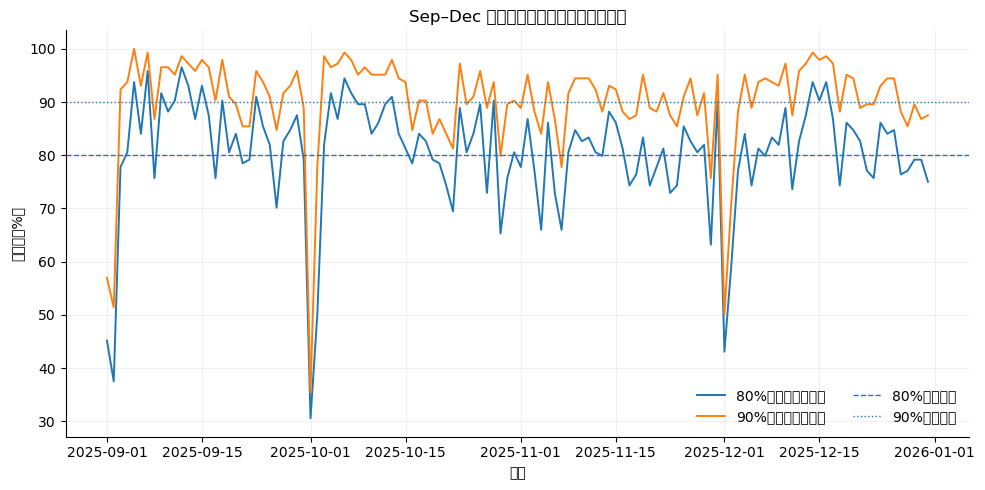

In [6]:
d = daily.copy()
d["date"] = pd.to_datetime(d["date"])

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(d["date"], d["cover80"]*100, linewidth=1.4, label="80%区间每日覆盖率")
ax.plot(d["date"], d["cover90"]*100, linewidth=1.4, label="90%区间每日覆盖率")
ax.axhline(80, linestyle="--", linewidth=1, label="80%名义水平")
ax.axhline(90, linestyle=":", linewidth=1, label="90%名义水平")
ax.set_ylabel("覆盖率（%）")
ax.set_xlabel("日期")
ax.set_title("Sep–Dec 滚动共形校准区间的每日覆盖率")
ax.grid(alpha=.2)
ax.legend(frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 5. 每日 CRPS

C:\Users\HP\AppData\Local\Temp\ipykernel_20980\649013053.py:9: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\649013053.py:9: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\649013053.py:9: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\649013053.py:9: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\649013053.py:9: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\649013053.py:9: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}

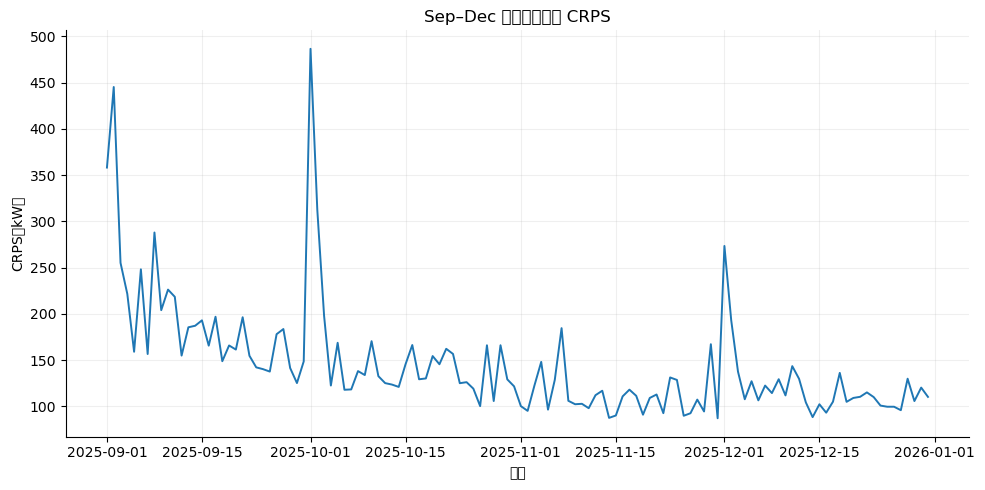

In [7]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(d["date"], d["crps_kw"], linewidth=1.4)
ax.set_ylabel("CRPS（kW）")
ax.set_xlabel("日期")
ax.set_title("Sep–Dec 概率预测每日 CRPS")
ax.grid(alpha=.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 6. 统计口径说明

Sep–Dec 在项目早期探索阶段曾被查看过旧模型表现，因此不能再严格称为“完全未曾查看的 pristine holdout”。

更准确的论文表述是：

> 最终冻结模型的参数选择与稳定性检查仅基于 May–Aug 开发区间，Sep–Dec 未参与本轮冻结模型的参数选择，并用于冻结模型的样本外评价。


## 7. 与风险策略层的衔接

风险分位数策略应继续使用 28 日成对残差场景的**原始经验分位数**：

$$
Q_q\left(N_{d,t}^{(1)},\ldots,N_{d,t}^{(S)}\right).
$$

M=14 共形校准只用于 80% / 90% 区间覆盖率修正，不应机械扩展到 p15、p25、p35、p65、p75、p85 等全部分位数。
